In [47]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

In [48]:
df = pd.read_excel(r"C:\Users\HP\OneDrive\Documents\aadi\cricket dataset.xlsx")

print("Column Names:")
print(df.columns)
print(df.head())
print(df.info())

Column Names:
Index(['Match_id', 'Series', 'Venue', 'Teame A', 'Teame B', 'Toss_winner',
       'Toss_decision', 'TeamA_Powerplay_runs', 'TeamA_powerplay_wickets',
       'TeamB_Powerplay_runs', 'TeamB_Powerplay_wickets', 'teamA_total_runs',
       'teamB_total_runs', 'winner'],
      dtype='object')
   Match_id                       Series  \
0         1  ICC Mens T20 World Cup 2024   
1         2  ICC Mens T20 World Cup 2024   
2         3  ICC Mens T20 World Cup 2024   
3         4  ICC Mens T20 World Cup 2024   
4         5  ICC Mens T20 World Cup 2024   

                                               Venue      Teame A  \
0                      Grand Prairie Stadium, Dallas       Canada   
1                         Providence Stadium, Guyana          png   
2              Kensington Oval, Bridgetown, Barbados      Namibia   
3  Nassau County International Cricket Stadium, N...   Sri Lanka    
4                         Providence Stadium, Guyana  Afghanistan   

        Teame B  T

In [50]:
df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

In [51]:
df = df.dropna()

In [52]:
label = LabelEncoder()

for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = label.fit_transform(df[column])

In [53]:
X = df.drop('winner', axis=1)
y = df['winner']

In [54]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [55]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [56]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(len(np.unique(y)), activation='softmax')
])

In [57]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [62]:
history = model.fit(
    X_train,
    y_train,
    epochs=56,
    validation_split=0.2,
    batch_size=8
)

Epoch 1/56
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.6061 - loss: 1.3655 - val_accuracy: 0.3333 - val_loss: 3.7743
Epoch 2/56
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.6061 - loss: 1.3430 - val_accuracy: 0.3333 - val_loss: 3.8147
Epoch 3/56
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.6667 - loss: 1.3191 - val_accuracy: 0.3333 - val_loss: 3.8720
Epoch 4/56
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.6667 - loss: 1.2882 - val_accuracy: 0.3333 - val_loss: 3.9280
Epoch 5/56
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.6667 - loss: 1.2640 - val_accuracy: 0.3333 - val_loss: 4.0068
Epoch 6/56
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.6667 - loss: 1.2354 - val_accuracy: 0.3333 - val_loss: 4.0764
Epoch 7/56
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.6667 - loss: 1.2143 - val_accuracy: 0.3333 - val_loss: 4.1497
Epoch 8/56
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.6970 - loss: 1.1861 - val_accuracy: 0.3333 - val_loss: 4.1813


In [63]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Model Accuracy:", accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.0000e+00 - loss: 9.0070
Model Accuracy: 0.0


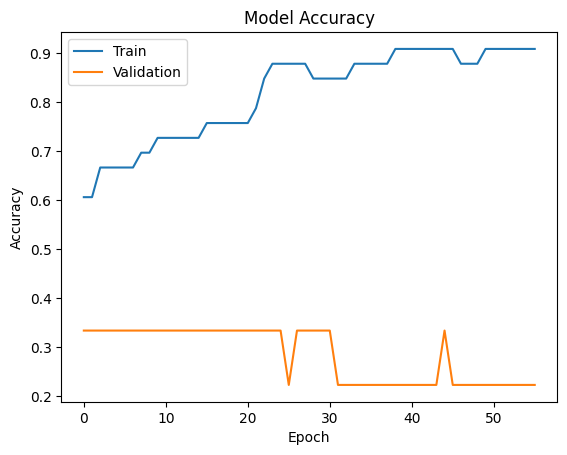

In [64]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train", "Validation"])

plt.show()

In [65]:
predictions = model.predict(X_test)

predicted_class = np.argmax(predictions, axis=1)

print(predicted_class[:10])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
[15 15 15 14 15 18  0 18 18 16]
